---
## 1. Environment

In [1]:
%%capture
!pip install osmnx catboost xgboost rasterio geopandas scikit-learn openpyxl folium

In [2]:
import os
import tempfile

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import BallTree
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_recall_curve, classification_report, confusion_matrix
)
from catboost import CatBoostClassifier
import xgboost as xgb

print('Environment ready.')

Environment ready.


---
## 2. Configuration

In [3]:
LABELS_CSV      = '/content/amman_edges_with_labels - amman_edges_with_labels.csv'
LABELS_XLSX     = '/content/Copy of amman_streets_labeled.xlsx'
REPORTS_XLSX    = '/content/access report.xlsx'
DEM_TIF         = '/content/output_hh.tif'

CITY            = 'Amman, Jordan'
CRS_UTM         = 'EPSG:32636'
DOMAIN_BUFFER   = 1000

PSEUDO_CONF_HIGH = 0.85
PSEUDO_CONF_LOW  = 0.15
PSEUDO_N         = 300
PSEUDO_WEIGHT    = 0.35
RANDOM_SEED      = 42

USE_DEM = os.path.exists(DEM_TIF)

print('Configuration:')
for name, path in [('Labels CSV', LABELS_CSV), ('Labels XLSX', LABELS_XLSX),
                   ('Reports XLSX', REPORTS_XLSX), ('DEM TIF', DEM_TIF)]:
    status = 'found' if os.path.exists(path) else 'NOT FOUND'
    print(f'  {name:<14} {status}')
print(f'  DEM enabled:   {USE_DEM}')

Configuration:
  Labels CSV     found
  Labels XLSX    found
  Reports XLSX   found
  DEM TIF        found
  DEM enabled:   True


---
## 3. Street Network

We pull the full street graph for Amman from OpenStreetMap using OSMnx, then reproject to UTM Zone 36N so distance calculations are in metres.

In [4]:
G = ox.graph_from_place(
    CITY,
    network_type='all',
    retain_all=False,
    truncate_by_edge=True,
    custom_filter='["highway"]'
)

edges = ox.graph_to_gdfs(G, nodes=False).reset_index()
edges = edges.to_crs(CRS_UTM)

print(f'Downloaded {len(edges):,} street segments.')

Downloaded 208,983 street segments.


---
## 4. Feature Extraction

Raw OSM tags are parsed and encoded as numeric features. Tags not present in Amman's OSM data are set to -1 so the model can distinguish "missing" from "zero".

In [5]:
edges['centroid_x'] = edges.geometry.centroid.x
edges['centroid_y'] = edges.geometry.centroid.y
edges['seg_length'] = edges.geometry.length

def compute_bearing(line):
    try:
        coords = list(line.coords)
        x1, y1 = coords[0]
        x2, y2 = coords[-1]
        return float(np.degrees(np.arctan2(x2 - x1, y2 - y1)) % 360)
    except:
        return 0.0

edges['bearing'] = edges.geometry.apply(compute_bearing)

def normalize_highway(h):
    if isinstance(h, list):
        h = h[0]
    return str(h) if pd.notna(h) else 'unclassified'

edges['highway_clean'] = edges['highway'].apply(normalize_highway)

HIGHWAY_RANK = {
    'motorway': 0, 'motorway_link': 0,
    'trunk': 1,    'trunk_link': 1,
    'primary': 2,  'primary_link': 2,
    'secondary': 3,'secondary_link': 3,
    'tertiary': 4, 'tertiary_link': 4,
    'unclassified': 5, 'residential': 5,
    'living_street': 6, 'service': 6,
    'footway': 7,  'pedestrian': 7, 'path': 7,
    'cycleway': 6, 'track': 5, 'busway': 3, 'steps': 4,
}
edges['highway_rank']  = edges['highway_clean'].map(HIGHWAY_RANK).fillna(5).astype(int)
edges['is_major_road'] = (edges['highway_rank'] <= 2).astype(int)

SURFACE_MAP = {
    'asphalt': 1, 'paved': 1, 'concrete': 1, 'paving_stones': 1, 'sett': 1,
    'cobblestone': 0, 'unpaved': 0, 'compacted': 0,
    'gravel': 0, 'dirt': 0, 'ground': 0, 'grass': 0, 'sand': 0,
}
def encode_surface(s):
    if isinstance(s, list): s = s[0]
    return SURFACE_MAP.get(str(s).lower(), -1) if pd.notna(s) else -1

edges['surface_code'] = edges['surface'].apply(encode_surface) if 'surface' in edges.columns else -1

SMOOTHNESS_MAP = {
    'excellent': 1, 'good': 1, 'intermediate': 0,
    'bad': 0, 'very_bad': 0, 'horrible': 0, 'impassable': 0,
}
def encode_smoothness(s):
    if isinstance(s, list): s = s[0]
    return SMOOTHNESS_MAP.get(str(s).lower(), -1) if pd.notna(s) else -1

edges['smoothness_code'] = edges['smoothness'].apply(encode_smoothness) if 'smoothness' in edges.columns else -1

SIDEWALK_MAP = {'yes': 1, 'both': 1, 'left': 1, 'right': 1, 'no': 0, 'none': 0}
def encode_sidewalk(s):
    if isinstance(s, list): s = s[0]
    return SIDEWALK_MAP.get(str(s).lower(), -1) if pd.notna(s) else -1

edges['sidewalk_code'] = edges['sidewalk'].apply(encode_sidewalk) if 'sidewalk' in edges.columns else -1

def encode_width(w):
    if isinstance(w, list): w = w[0]
    try:
        v = float(str(w).split()[0])
        return 2 if v >= 4 else (1 if v >= 2 else 0)
    except:
        return -1

edges['width_bin'] = edges['width'].apply(encode_width) if 'width' in edges.columns else -1

WHEELCHAIR_MAP = {'yes': 1, 'designated': 1, 'limited': 0, 'no': -1}
def encode_wheelchair(w):
    if isinstance(w, list): w = w[0]
    return WHEELCHAIR_MAP.get(str(w).lower(), -1) if pd.notna(w) else -1

edges['wheelchair_tag'] = edges['wheelchair'].apply(encode_wheelchair) if 'wheelchair' in edges.columns else -1

def encode_maxspeed(s):
    if isinstance(s, list): s = s[0]
    try: return float(str(s).split()[0])
    except: return -1.0

edges['maxspeed_val'] = edges['maxspeed'].apply(encode_maxspeed) if 'maxspeed' in edges.columns else -1.0

def to_binary(col):
    if col not in edges.columns:
        return 0
    return edges[col].apply(lambda x: 1 if str(x).lower() in ('yes', 'true', '1') else 0)

edges['is_bridge'] = to_binary('bridge')
edges['is_tunnel'] = to_binary('tunnel')
edges['is_oneway'] = edges['oneway'].astype(int) if 'oneway' in edges.columns else 0

print('Feature extraction done.')

Feature extraction done.


---
## 5. Slope from DEM

Slope is the strongest accessibility predictor in Amman's hilly terrain. For each segment we sample elevation at 10 evenly spaced points and derive four slope metrics. Segments exceeding the 8% gradient are flagged — this is the ADA/ISO 21542 threshold for wheelchair accessibility.

In [6]:
if USE_DEM:
    import rasterio
    from rasterio.warp import reproject, Resampling, calculate_default_transform

    dem_src = rasterio.open(DEM_TIF)

    if str(dem_src.crs) != CRS_UTM:
        transform, width, height = calculate_default_transform(
            dem_src.crs, CRS_UTM, dem_src.width, dem_src.height, *dem_src.bounds
        )
        meta = dem_src.meta.copy()
        meta.update({'crs': CRS_UTM, 'transform': transform, 'width': width, 'height': height})
        dem_utm_path = os.path.join(tempfile.gettempdir(), 'dem_utm.tif')
        with rasterio.open(dem_utm_path, 'w', **meta) as dst:
            for band in range(1, dem_src.count + 1):
                reproject(
                    source=rasterio.band(dem_src, band),
                    destination=rasterio.band(dst, band),
                    src_transform=dem_src.transform,
                    src_crs=dem_src.crs,
                    dst_transform=transform,
                    dst_crs=CRS_UTM,
                    resampling=Resampling.bilinear
                )
        dem_src.close()
        dem_src = rasterio.open(dem_utm_path)

    dem_array = dem_src.read(1)

    def extract_slope_features(line, n_samples=10):
        try:
            points = [line.interpolate(i / n_samples, normalized=True) for i in range(n_samples + 1)]
            elevations = []
            for pt in points:
                try:
                    r, c = dem_src.index(pt.x, pt.y)
                    if 0 <= r < dem_array.shape[0] and 0 <= c < dem_array.shape[1]:
                        elevations.append(float(dem_array[r, c]))
                except:
                    continue
            if len(elevations) < 2 or line.length < 5:
                return 0.0, 0.0, 0.0, 0.0
            seg_len = line.length / len(elevations)
            slopes  = [abs(elevations[i+1] - elevations[i]) / seg_len for i in range(len(elevations) - 1)]
            return (
                float(np.mean(slopes)),
                float(np.max(slopes)),
                float(np.var(slopes)),
                float(abs(elevations[-1] - elevations[0]) / line.length)
            )
        except:
            return 0.0, 0.0, 0.0, 0.0

    results = edges.geometry.apply(extract_slope_features)
    edges['slope_mean'] = np.clip([r[0] for r in results], 0, 0.4)
    edges['slope_max']  = np.clip([r[1] for r in results], 0, 0.4)
    edges['slope_var']  = np.clip([r[2] for r in results], 0, 0.05)
    edges['slope_net']  = np.clip([r[3] for r in results], 0, 0.4)
    edges['slope']      = edges['slope_mean']
    edges['slope_ada_fail'] = (edges['slope_max'] > 0.08).astype(int)
    edges['slope_class']    = pd.cut(
        edges['slope'],
        bins=[-0.001, 0.02, 0.05, 0.08, 0.4],
        labels=[0, 1, 2, 3]
    ).astype('Int64').fillna(0)

    dem_src.close()
    print(f'Slope computed. Segments exceeding ADA 8% limit: {edges["slope_ada_fail"].mean():.1%}')

else:
    for col in ['slope', 'slope_mean', 'slope_max', 'slope_var', 'slope_net']:
        edges[col] = 0.0
    edges['slope_ada_fail'] = 0
    edges['slope_class']    = 0
    print('DEM not available — slope features set to zero.')

Slope computed. Segments exceeding ADA 8% limit: 55.4%


---
## 6. Labels

Three label sources are merged by priority: team CSV → team XLSX → crowdsourced reports. Where multiple sources cover the same segment, the higher-priority label wins.

In [7]:
df_csv = pd.read_csv(LABELS_CSV)
df_csv = df_csv[df_csv['label_status'] == 'labeled'][['u', 'v', 'label']].dropna()
df_csv['label']  = df_csv['label'].astype(int)
df_csv['source'] = 'manual'

df_xlsx = pd.read_excel(LABELS_XLSX)
label_col = next(
    (c for c in df_xlsx.columns if df_xlsx[c].isin([0, 1]).mean() > 0.8), None
)

if label_col and 'u' in df_xlsx.columns and 'v' in df_xlsx.columns:
    df_xlsx = df_xlsx[df_xlsx[label_col].isin([0, 1])][['u', 'v', label_col]].copy()
    df_xlsx = df_xlsx.rename(columns={label_col: 'label'})
    df_xlsx['source'] = 'manual'
else:
    print(f'Could not detect label column in XLSX. Columns: {list(df_xlsx.columns)}')
    df_xlsx = pd.DataFrame(columns=['u', 'v', 'label', 'source'])

all_labels = pd.concat([df_csv, df_xlsx], ignore_index=True)
all_labels = all_labels.drop_duplicates(subset=['u', 'v'], keep='first')

for col in ['label', 'source']:
    if col in edges.columns:
        edges = edges.drop(columns=[col])

all_labels['u'] = all_labels['u'].astype('int64')
all_labels['v'] = all_labels['v'].astype('int64')
edges['u']      = edges['u'].astype('int64')
edges['v']      = edges['v'].astype('int64')
edges = edges.merge(all_labels[['u', 'v', 'label', 'source']], on=['u', 'v'], how='left')

print(f'Manual labels matched: {edges["label"].notna().sum()}')
print(f'  Accessible (0):   {(edges["label"]==0).sum()}')
print(f'  Inaccessible (1): {(edges["label"]==1).sum()}')

Could not detect label column in XLSX. Columns: ['u', 'v', 'length', 'highway', 'geometry', 'safety_label']
Manual labels matched: 85
  Accessible (0):   47
  Inaccessible (1): 38


In [8]:
if os.path.exists(REPORTS_XLSX):
    reports = pd.read_excel(REPORTS_XLSX, sheet_name='Reports').dropna(subset=['lat', 'lon'])

    reports['label_binary'] = reports['overall'].map({
        'accessible':   0,
        'inaccessible': 1,
        'partial':      1,
    }).fillna(0).astype(int)

    reports_gdf = gpd.GeoDataFrame(
        reports,
        geometry=gpd.points_from_xy(reports['lon'], reports['lat']),
        crs='EPSG:4326'
    ).to_crs(CRS_UTM)

    edge_coords   = np.column_stack([edges['centroid_x'], edges['centroid_y']])
    report_coords = np.column_stack([[g.x for g in reports_gdf.geometry],
                                     [g.y for g in reports_gdf.geometry]])

    tree = BallTree(edge_coords, metric='euclidean')
    distances, indices = tree.query(report_coords, k=1)
    distances = distances[:, 0]

    matched = reports_gdf[distances <= 50].copy()
    matched['edge_idx'] = indices[distances <= 50, 0]

    crowd_labels = (
        matched.groupby('edge_idx')['label_binary']
        .agg(lambda x: int(x.mean() >= 0.5))
        .reset_index()
    )

    added = 0
    for _, row in crowd_labels.iterrows():
        idx = int(row['edge_idx'])
        if pd.isna(edges.loc[idx, 'label']):
            edges.loc[idx, 'label']  = row['label_binary']
            edges.loc[idx, 'source'] = 'crowd'
            added += 1

    print(f'Crowdsourced reports: {len(reports)} total, {len(matched)} matched to segments, {added} new labels')

print(f'Total labeled segments: {edges["label"].notna().sum()}')
print(edges['source'].value_counts())

Crowdsourced reports: 142 total, 136 matched to segments, 121 new labels
Total labeled segments: 206
source
crowd     121
manual     85
Name: count, dtype: int64


---
## 7. Feature Engineering

Six additional features derived from existing columns.

In [9]:
PED_SCORE_MAP = {
    'footway': 4, 'pedestrian': 4, 'path': 4, 'steps': 2,
    'living_street': 3, 'residential': 2, 'unclassified': 2,
    'tertiary': 1, 'tertiary_link': 1, 'secondary': 1, 'secondary_link': 1,
    'primary': 0, 'primary_link': 0, 'trunk': 0, 'trunk_link': 0,
    'motorway': 0, 'motorway_link': 0, 'busway': 0, 'track': 1, 'service': 2,
}
edges['ped_score']   = edges['highway_clean'].map(PED_SCORE_MAP).fillna(1).astype(int)
edges['is_ped_zone'] = edges['highway_clean'].isin(
    ['footway', 'pedestrian', 'path', 'living_street']
).astype(int)

# Long steep segments are worse than short steep ones
edges['slope_x_length'] = (edges['slope_max'] * edges['seg_length']).clip(0, 200)

# North-south streets tend to be steeper in hilly Amman
edges['ns_orientation'] = np.abs(np.sin(np.radians(edges['bearing'].fillna(0))))

edges['is_short_street'] = (edges['seg_length'] < 50).astype(int)

tag_cols = [c for c in ['sidewalk_code', 'surface_code', 'smoothness_code',
                         'width_bin', 'wheelchair_tag'] if c in edges.columns]
edges['n_missing_tags'] = sum((edges[c] == -1).astype(int) for c in tag_cols)

print('Feature engineering done.')

Feature engineering done.


---
## 8. Domain Restriction

Labels are concentrated in a ~12 × 16 km patch of Amman. Training and predicting across the full 113 × 91 km network adds noise from areas with no coverage. We restrict to a bounding box around the labeled area plus a 1 km buffer. This raises labeling density from 0.14% to ~0.22% and keeps the domain realistic.

In [10]:
labeled = edges[edges['label'].notna()]

x_min = labeled['centroid_x'].min() - DOMAIN_BUFFER
x_max = labeled['centroid_x'].max() + DOMAIN_BUFFER
y_min = labeled['centroid_y'].min() - DOMAIN_BUFFER
y_max = labeled['centroid_y'].max() + DOMAIN_BUFFER

edges = edges[
    (edges['centroid_x'].between(x_min, x_max)) &
    (edges['centroid_y'].between(y_min, y_max))
].copy().reset_index(drop=True)

n_labeled = edges['label'].notna().sum()
print(f'Restricted to labeled area + {DOMAIN_BUFFER}m buffer')
print(f'  Segments: 208,942 → {len(edges):,}')
print(f'  Labeled:  {n_labeled} ({n_labeled / len(edges):.2%} density)')

Restricted to labeled area + 1000m buffer
  Segments: 208,942 → 93,624
  Labeled:  206 (0.22% density)


---
## 9. Feature Set

In [11]:
FEATURE_CANDIDATES = [
    'highway_rank', 'is_major_road', 'ped_score', 'is_ped_zone',
    'sidewalk_code', 'surface_code', 'smoothness_code', 'width_bin', 'wheelchair_tag',
    'slope', 'slope_mean', 'slope_max', 'slope_var', 'slope_net',
    'slope_class', 'slope_ada_fail', 'slope_x_length',
    'maxspeed_val', 'is_bridge', 'is_tunnel', 'is_oneway',
    'seg_length', 'is_short_street',
    'bearing', 'ns_orientation', 'centroid_x', 'centroid_y',
    'n_missing_tags',
]

FEATURES = [f for f in FEATURE_CANDIDATES if f in edges.columns]
print(f'{len(FEATURES)} features selected.')

28 features selected.


---
## 10. Spatial Cross-Validation

Labeled segments are partitioned into 1 × 1 km spatial blocks. Each fold holds out one group of blocks as the test set. This prevents nearby segments from appearing in both train and test, which would inflate results due to spatial autocorrelation.

In [12]:
train_df = edges[edges['label'].notna()].copy()
train_df['label'] = train_df['label'].astype(int).clip(0, 1)

BLOCK_SIZE = 1000
train_df['block'] = (
    (train_df['centroid_x'] // BLOCK_SIZE).astype(int).astype(str) + '_' +
    (train_df['centroid_y'] // BLOCK_SIZE).astype(int).astype(str)
)

blocks = train_df['block'].unique()
rng    = np.random.default_rng(RANDOM_SEED)
rng.shuffle(blocks)

n_folds    = min(5, len(blocks))
fold_sizes = np.array_split(blocks, n_folds)

cv_log = []
print(f'5-fold spatial CV on {len(train_df)} labeled segments\n')

for fold_idx, test_blocks in enumerate(fold_sizes):
    mask       = train_df['block'].isin(test_blocks)
    fold_train = train_df[~mask]
    fold_test  = train_df[mask]

    if len(fold_train) == 0 or len(fold_test) == 0:
        continue

    X_tr = fold_train[FEATURES].fillna(-1).astype(float)
    X_te = fold_test[FEATURES].fillna(-1).astype(float)
    y_tr = fold_train['label']
    y_te = fold_test['label']

    model = CatBoostClassifier(
        iterations=600,
        depth=6,
        learning_rate=0.05,
        class_weights={0: 1.0, 1: 2.0},
        verbose=0,
        random_seed=RANDOM_SEED
    )
    model.fit(X_tr, y_tr)

    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_prob) if y_te.nunique() > 1 else 0.5

    cv_log.append({'fold': fold_idx + 1, 'n': len(y_te), 'acc': acc, 'f1': f1, 'auc': auc})
    print(f'  Fold {fold_idx + 1}: acc={acc:.3f}  f1={f1:.3f}  auc={auc:.3f}  (n={len(y_te)})')

cv_df = pd.DataFrame(cv_log)
print(f'\n  Mean: acc={cv_df["acc"].mean():.3f}  f1={cv_df["f1"].mean():.3f}  auc={cv_df["auc"].mean():.3f}')

5-fold spatial CV on 206 labeled segments

  Fold 1: acc=0.833  f1=0.462  auc=0.854  (n=42)
  Fold 2: acc=0.847  f1=0.690  auc=0.925  (n=59)
  Fold 3: acc=0.860  f1=0.250  auc=0.878  (n=43)
  Fold 4: acc=0.805  f1=0.600  auc=0.893  (n=41)
  Fold 5: acc=0.905  f1=0.750  auc=0.889  (n=21)

  Mean: acc=0.850  f1=0.550  auc=0.888


---
## 11. Pseudo-Labeling

With only ~200 verified labels the model is data-hungry. We train a base model on those labels, apply it to all unlabeled segments, and promote high-confidence predictions (< 0.15 or > 0.85) back into the training set at a reduced weight of 0.35. This keeps pseudo-labels from dominating the human-verified signal.

In [13]:
X_labeled = train_df[FEATURES].fillna(-1).astype(float)
y_labeled = train_df['label']

base_model = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.04,
    class_weights={0: 1.0, 1: 2.0},
    verbose=0,
    random_seed=RANDOM_SEED
)
base_model.fit(X_labeled, y_labeled)

X_all = edges[FEATURES].fillna(-1).astype(float)
edges['prob_base'] = base_model.predict_proba(X_all)[:, 1]

unlabeled    = edges[edges['label'].isna()].copy()
conf_safe    = unlabeled[unlabeled['prob_base'] < PSEUDO_CONF_LOW]
conf_unsafe  = unlabeled[unlabeled['prob_base'] > PSEUDO_CONF_HIGH]
n_pseudo     = min(PSEUDO_N, len(conf_safe), len(conf_unsafe))

pseudo_safe             = conf_safe.sample(n_pseudo, random_state=RANDOM_SEED).copy()
pseudo_unsafe           = conf_unsafe.sample(n_pseudo, random_state=RANDOM_SEED).copy()
pseudo_safe['label']    = 0
pseudo_unsafe['label']  = 1
pseudo_df               = pd.concat([pseudo_safe, pseudo_unsafe])
pseudo_df['is_pseudo']  = 1

real_df              = train_df.copy()
real_df['is_pseudo'] = 0

common_cols = [c for c in FEATURES + ['label', 'is_pseudo']
               if c in real_df.columns and c in pseudo_df.columns]
combined    = pd.concat([real_df[common_cols], pseudo_df[common_cols]], ignore_index=True)
weights     = combined['is_pseudo'].map({0: 1.0, 1: PSEUDO_WEIGHT}).values

print(f'Pseudo-labels: {n_pseudo} per class (thresholds: {PSEUDO_CONF_LOW} / {PSEUDO_CONF_HIGH})')
print(f'Training set:  {len(real_df)} verified + {len(pseudo_df)} pseudo = {len(combined)} total')

Pseudo-labels: 300 per class (thresholds: 0.15 / 0.85)
Training set:  206 verified + 600 pseudo = 806 total


---
## 12. Ensemble Training

CatBoost and XGBoost are trained separately on the combined dataset. Their probability outputs are blended as a weighted average (60% CatBoost, 40% XGBoost).

In [14]:
X_train = combined[FEATURES].fillna(-1).astype(float)
y_train = combined['label'].astype(int)

cb_model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    class_weights={0: 1.0, 1: 2.0},
    verbose=0,
    random_seed=RANDOM_SEED
)
cb_model.fit(X_train, y_train, sample_weight=weights)
print('CatBoost trained.')

real_label_dist = combined[combined['is_pseudo'] == 0]['label']
scale_pos_weight = (real_label_dist == 0).sum() / max((real_label_dist == 1).sum(), 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.03,
    scale_pos_weight=scale_pos_weight * 2,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train, sample_weight=weights)
print('XGBoost trained.')

X_pred = edges[FEATURES].fillna(-1).astype(float)
edges['prob_cb']       = cb_model.predict_proba(X_pred)[:, 1]
edges['prob_xgb']      = xgb_model.predict_proba(X_pred)[:, 1]
edges['prob_ensemble'] = 0.6 * edges['prob_cb'] + 0.4 * edges['prob_xgb']

print(f'Predictions ready for {len(edges):,} segments.')

CatBoost trained.
XGBoost trained.
Predictions ready for 93,624 segments.


---
## 13. Evaluation

Out-of-fold predictions give an unbiased performance estimate. We pick the classification threshold by maximising F1 on the precision-recall curve rather than defaulting to 0.5 — this matters because accessible segments outnumber inaccessible ones.

Evaluation — out-of-fold, 5-fold spatial CV
  AUC-ROC:           0.8954
  Accuracy:          0.8544
  F1-score:          0.6667
  Decision threshold:0.244


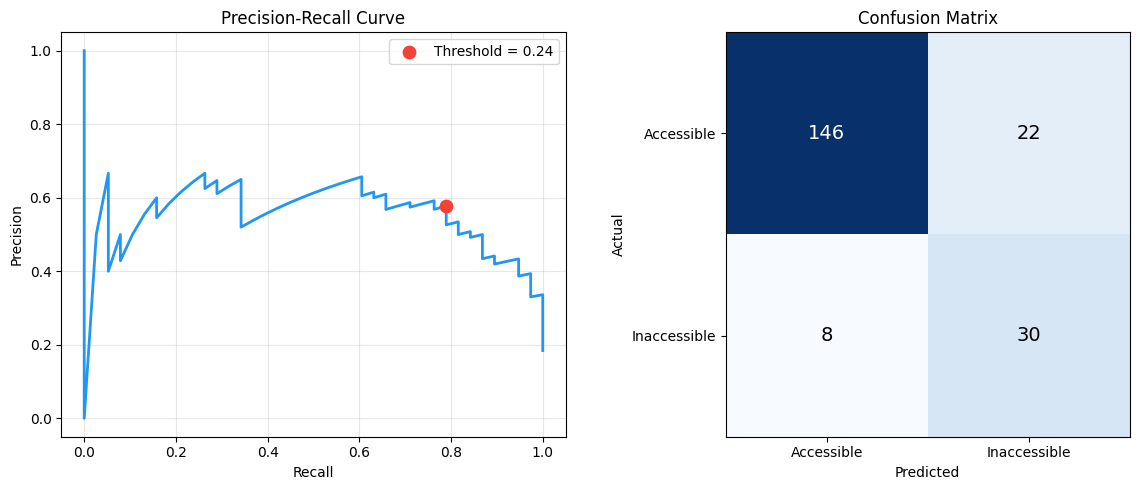

              precision    recall  f1-score   support

  Accessible       0.95      0.87      0.91       168
Inaccessible       0.58      0.79      0.67        38

    accuracy                           0.85       206
   macro avg       0.76      0.83      0.79       206
weighted avg       0.88      0.85      0.86       206



In [15]:
train_df2 = edges[edges['label'].notna()].copy()
train_df2['label'] = train_df2['label'].astype(int).clip(0, 1)
train_df2['block'] = (
    (train_df2['centroid_x'] // BLOCK_SIZE).astype(int).astype(str) + '_' +
    (train_df2['centroid_y'] // BLOCK_SIZE).astype(int).astype(str)
)

blocks2     = train_df2['block'].unique()
rng2        = np.random.default_rng(RANDOM_SEED)
rng2.shuffle(blocks2)
fold_sizes2 = np.array_split(blocks2, min(5, len(blocks2)))

oof_labels = []
oof_probs  = []

for fold_idx, test_blocks in enumerate(fold_sizes2):
    mask       = train_df2['block'].isin(test_blocks)
    fold_train = train_df2[~mask]
    fold_test  = train_df2[mask]

    if len(fold_train) == 0 or len(fold_test) == 0:
        continue

    X_tr = fold_train[FEATURES].fillna(-1).astype(float)
    X_te = fold_test[FEATURES].fillna(-1).astype(float)
    y_tr = fold_train['label']
    y_te = fold_test['label']

    cb = CatBoostClassifier(
        iterations=600, depth=6, learning_rate=0.05,
        class_weights={0: 1.0, 1: 2.0}, verbose=0, random_seed=RANDOM_SEED
    )
    cb.fit(X_tr, y_tr)

    spos = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    xg   = xgb.XGBClassifier(
        n_estimators=600, max_depth=5, learning_rate=0.05,
        scale_pos_weight=spos * 2, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_SEED, eval_metric='logloss', verbosity=0
    )
    xg.fit(X_tr, y_tr)

    fold_prob = 0.6 * cb.predict_proba(X_te)[:, 1] + 0.4 * xg.predict_proba(X_te)[:, 1]
    oof_labels.extend(y_te.tolist())
    oof_probs.extend(fold_prob.tolist())

y_true = np.array(oof_labels)
y_prob = np.array(oof_probs)

auc_score = roc_auc_score(y_true, y_prob)

precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
f1_vals     = 2 * precision * recall / (precision + recall + 1e-8)
best_idx    = np.argmax(f1_vals)
BEST_THRESH = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5

y_pred = (y_prob >= BEST_THRESH).astype(int)

print('='*55)
print('Evaluation — out-of-fold, 5-fold spatial CV')
print('='*55)
print(f'  AUC-ROC:           {auc_score:.4f}')
print(f'  Accuracy:          {accuracy_score(y_true, y_pred):.4f}')
print(f'  F1-score:          {f1_score(y_true, y_pred, zero_division=0):.4f}')
print(f'  Decision threshold:{BEST_THRESH:.3f}')
print('='*55)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(recall, precision, color='#2196F3', linewidth=2)
axes[0].scatter(recall[best_idx], precision[best_idx], color='#F44336', s=80, zorder=5,
                label=f'Threshold = {BEST_THRESH:.2f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

cm = confusion_matrix(y_true, y_pred)
axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Accessible', 'Inaccessible'])
axes[1].set_yticklabels(['Accessible', 'Inaccessible'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=['Accessible', 'Inaccessible']))

---
## 14. Feature Importance

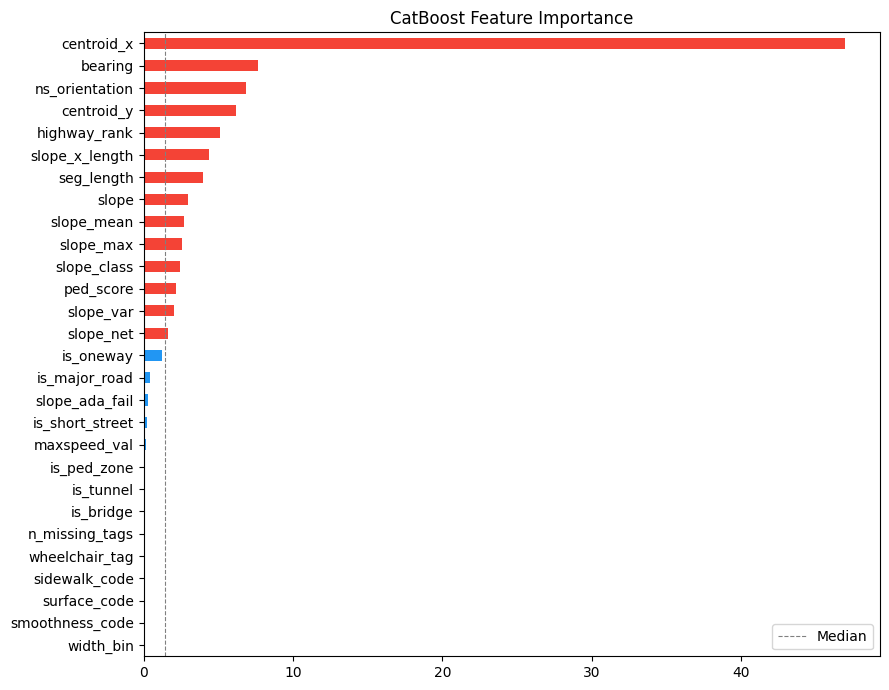

In [16]:
importance = pd.Series(
    cb_model.get_feature_importance(),
    index=FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#F44336' if v > importance.median() else '#2196F3' for v in importance]
importance.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
ax.axvline(importance.median(), color='gray', linestyle='--', linewidth=0.8, label='Median')
ax.set_title('CatBoost Feature Importance')
ax.legend()
plt.tight_layout()
plt.show()

---
## 15. Export

The ensemble is applied to all segments. Human-verified labels override model predictions where available. Each segment gets a five-level confidence tier for the app UI.

In [17]:
edges['pred_prob_unsafe'] = edges['prob_ensemble']
edges['pred_label']       = (edges['prob_ensemble'] >= BEST_THRESH).astype(int)
edges['final_label']      = edges['label'].where(
    edges['label'].notna(), edges['pred_label']
).astype(int)

def assign_confidence_tier(p):
    if p >= 0.80: return 'definitely_inaccessible'
    if p >= 0.60: return 'likely_inaccessible'
    if p >= 0.40: return 'uncertain'
    if p >= 0.20: return 'likely_accessible'
    return 'definitely_accessible'

edges['confidence_tier'] = edges['prob_ensemble'].apply(assign_confidence_tier)

n_accessible   = (edges['final_label'] == 0).sum()
n_inaccessible = (edges['final_label'] == 1).sum()
print(f'Predictions (threshold = {BEST_THRESH:.3f}):')
print(f'  Accessible:   {n_accessible:,} ({n_accessible / len(edges):.1%})')
print(f'  Inaccessible: {n_inaccessible:,} ({n_inaccessible / len(edges):.1%})')

OUTPUT_COLS = [
    'u', 'v', 'key', 'highway_clean', 'seg_length',
    'sidewalk_code', 'surface_code', 'ped_score',
    'slope', 'slope_max', 'slope_ada_fail',
    'centroid_x', 'centroid_y',
    'label', 'source', 'pred_prob_unsafe', 'final_label', 'confidence_tier'
]
OUTPUT_COLS = [c for c in OUTPUT_COLS if c in edges.columns]

edges[OUTPUT_COLS].to_csv('amman_accessibility_FINAL.csv', index=False)

edges_wgs84 = edges.to_crs('EPSG:4326')
edges_wgs84[OUTPUT_COLS + ['geometry']].to_file(
    'amman_accessibility_FINAL.geojson', driver='GeoJSON'
)

print('Saved: amman_accessibility_FINAL.csv')
print('Saved: amman_accessibility_FINAL.geojson')

try:
    from google.colab import files
    files.download('amman_accessibility_FINAL.csv')
    files.download('amman_accessibility_FINAL.geojson')
except ImportError:
    pass

Predictions (threshold = 0.244):
  Accessible:   68,776 (73.5%)
  Inaccessible: 24,848 (26.5%)
Saved: amman_accessibility_FINAL.csv
Saved: amman_accessibility_FINAL.geojson


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 16. Summary

In [18]:
print('=' * 60)
print('SafeStreet Amman — Results')
print('=' * 60)
print(f'  v1  200 manual labels                acc=0.570  auc=0.580')
print(f'  v2  + crowdsourced reports            acc=0.694  auc=0.761')
print(f'  v3  + features, pseudo, ensemble      acc={accuracy_score(y_true, y_pred):.3f}  auc={auc_score:.3f}')
print()
print('Configuration')
print(f'  Algorithm:    CatBoost + XGBoost (0.6 / 0.4)')
print(f'  Features:     {len(FEATURES)}')
print(f'  Training:     {len(real_df)} verified + {len(pseudo_df)} pseudo-labeled')
print(f'  Threshold:    {BEST_THRESH:.3f}')
print(f'  Evaluation:   5-fold spatial CV (OOF)')
print(f'  Domain:       Labeled area + {DOMAIN_BUFFER}m buffer')
print(f'  Segments:     {len(edges):,}')
print('=' * 60)

SafeStreet Amman — Results
  v1  200 manual labels                acc=0.570  auc=0.580
  v2  + crowdsourced reports            acc=0.694  auc=0.761
  v3  + features, pseudo, ensemble      acc=0.854  auc=0.895

Configuration
  Algorithm:    CatBoost + XGBoost (0.6 / 0.4)
  Features:     28
  Training:     206 verified + 600 pseudo-labeled
  Threshold:    0.244
  Evaluation:   5-fold spatial CV (OOF)
  Domain:       Labeled area + 1000m buffer
  Segments:     93,624
